In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
import missingno as msno
from scipy import stats
from sklearn.preprocessing import RobustScaler, MinMaxScaler
import warnings

In [3]:
#Load dataset

nutrition_df = pd.read_csv("https://raw.githubusercontent.com/ekasaaa/analisis-dataset-gizi/refs/heads/main/nilai-gizi.csv", sep=";")
nutrition_df.head()

,Nama_Makanan,Produsen,Porsi,Energi (kkal),Protein (g),Karbohidrat (g),Lemak (g),Gula (g),Natrium (mg),Serat (g),...,Natrium,Protein,Karbohidrat_Total,Energi,Lemak_Total,Serat_Pangan,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,Ikan sunu,asin,mentah,Tidak Diketahui,20.30 g,199.0,34.1,7.1,3.8,0.0,...,25.13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1,Soto pekalongan,masakan,Tidak Diketahui,1.30 g,94.0,3.0,5.1,6.8,0.0,0.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
2,Marie duo,Tidak Diketahui,1 g,15.0,1.0,14.0,3.5,5.0,85.0,1.0,...,6.00,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
3,Kaparende,sayur,Tidak Diketahui,1.30 g,38.0,2.4,2.6,2.0,0.0,170.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,Kacang lebui / iris,Tidak Diketahui,3.60 g,346.0,16.5,66.6,1.5,0.0,17.0,37.3,...,0.00,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


In [4]:
#Menilai data nutrition_df

nutrition_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1651 entries, 0 to 1650
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Nama_Makanan                1651 non-null   object 
 1   Produsen                    1651 non-null   object 
 2   Porsi                       1651 non-null   object 
 3   Energi (kkal)               1651 non-null   object 
 4   Protein (g)                 1651 non-null   object 
 5   Karbohidrat (g)             1651 non-null   object 
 6   Lemak (g)                   1651 non-null   object 
 7   Gula (g)                    1651 non-null   float64
 8   Natrium (mg)                1651 non-null   float64
 9   Serat (g)                   1651 non-null   float64
 10  Persentase_AKG_Energi       1651 non-null   float64
 11  Persentase_AKG_Protein      1651 non-null   float64
 12  Persentase_AKG_Karbohidrat  1651 non-null   float64
 13  Persentase_AKG_Lemak        1651 

In [5]:
#Mengecek missing values pada dataset nutrition_df

nutrition_df.isna().sum()

Nama_Makanan                     0
Produsen                         0
Porsi                            0
Energi (kkal)                    0
Protein (g)                      0
Karbohidrat (g)                  0
Lemak (g)                        0
Gula (g)                         0
Natrium (mg)                     0
Serat (g)                        0
Persentase_AKG_Energi            0
Persentase_AKG_Protein           0
Persentase_AKG_Karbohidrat       0
Persentase_AKG_Lemak             0
Persentase_AKG_Natrium           0
Lemak_Jenuh                      0
Natrium                          0
Protein                          0
Karbohidrat_Total                0
Energi                           0
Lemak_Total                      0
Serat_Pangan                     0
Unnamed: 22                   1196
Unnamed: 23                   1586
Unnamed: 24                   1641
Unnamed: 25                   1649
dtype: int64

In [6]:
#Mengecek duplikasi tabel nutrition_df

print("Jumlah duplikasi: ", nutrition_df.duplicated().sum())

Jumlah duplikasi:  0


In [7]:
#Mengecek menggunakan method describe

nutrition_df.describe()

,Gula (g),Natrium (mg),Serat (g),Persentase_AKG_Energi,Persentase_AKG_Protein,Persentase_AKG_Karbohidrat,Persentase_AKG_Lemak,Persentase_AKG_Natrium,Lemak_Jenuh,Natrium,Protein,Karbohidrat_Total,Energi,Lemak_Total,Serat_Pangan,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
count,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,455.0,65.0,10.0,2.0
mean,5.924906,99.068565,23.429085,12.353998,11.175542,10.120218,11.795845,8.384155,3.215530,4.300485,4.094482,2.468280,3.687462,5.227135,1.013931,0.0,0.0,0.0,0.0
std,13.792322,407.541251,106.819370,51.215859,32.562132,11.118718,18.874163,27.627000,10.961959,14.592509,12.379304,5.861247,7.990628,14.224772,6.354129,0.0,0.0,0.0,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,0.000000,0.000000,0.000000,2.200000,1.670000,3.330000,1.490000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,0.400000,0.000000,0.700000,5.580000,5.000000,6.460000,5.220000,0.670000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,6.000000,34.000000,4.000000,12.490000,13.330000,14.000000,14.930000,6.000000,0.270000,0.000000,0.000000,1.000000,5.000000,3.000000,0.000000,0.0,0.0,0.0,0.0
max,201.000000,11998.000000,1724.000000,1068.000000,1081.000000,123.830000,182.090000,799.870000,225.000000,136.000000,132.000000,57.000000,80.000000,183.000000,147.000000,0.0,0.0,0.0,0.0


In [8]:
#CLEANING DATA

#mengubah tulisan "tidak diketahui" menjadi NaN agar bisa diproses
nutrition_df['Porsi'] = nutrition_df['Porsi'].replace('tidak diketahui', np.nan)

#Ambil angkanya saja (membuang 'g', 'ml', dll)
#Regex ini akan mengambil angka desimal maupun bulat
nutrition_df['Porsi'] = nutrition_df['Porsi'].str.extract('(\d+\.?\d*)').astype(float)

#Isi data yang kosong (NaN) tadi dengan nilai tengah (Median)
median_porsi = nutrition_df['Porsi'].median()
nutrition_df['Porsi'] = nutrition_df['Porsi'].fillna(median_porsi)

print("Tipe data Porsi sekarang:", nutrition_df['Porsi'].dtype)

Tipe data Porsi sekarang: float64


In [9]:
#cek
nutrition_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1651 entries, 0 to 1650
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Nama_Makanan                1651 non-null   object 
 1   Produsen                    1651 non-null   object 
 2   Porsi                       1651 non-null   float64
 3   Energi (kkal)               1651 non-null   object 
 4   Protein (g)                 1651 non-null   object 
 5   Karbohidrat (g)             1651 non-null   object 
 6   Lemak (g)                   1651 non-null   object 
 7   Gula (g)                    1651 non-null   float64
 8   Natrium (mg)                1651 non-null   float64
 9   Serat (g)                   1651 non-null   float64
 10  Persentase_AKG_Energi       1651 non-null   float64
 11  Persentase_AKG_Protein      1651 non-null   float64
 12  Persentase_AKG_Karbohidrat  1651 non-null   float64
 13  Persentase_AKG_Lemak        1651 

In [10]:
#Menghapus kolom Unnamed yang tidak diperlukan

nutrition_df.drop(nutrition_df.columns[nutrition_df.columns.str.contains('unnamed', case=False)], axis=1, inplace=True)

In [11]:
#cek
nutrition_df.isna().sum()

Nama_Makanan                  0
Produsen                      0
Porsi                         0
Energi (kkal)                 0
Protein (g)                   0
Karbohidrat (g)               0
Lemak (g)                     0
Gula (g)                      0
Natrium (mg)                  0
Serat (g)                     0
Persentase_AKG_Energi         0
Persentase_AKG_Protein        0
Persentase_AKG_Karbohidrat    0
Persentase_AKG_Lemak          0
Persentase_AKG_Natrium        0
Lemak_Jenuh                   0
Natrium                       0
Protein                       0
Karbohidrat_Total             0
Energi                        0
Lemak_Total                   0
Serat_Pangan                  0
dtype: int64

In [12]:
#Mengecek duplikasi tabel nutrition_df

print("Jumlah duplikasi: ", nutrition_df.duplicated().sum())

Jumlah duplikasi:  0


In [13]:
#Mengecek menggunakan method describe

nutrition_df.describe()

,Porsi,Gula (g),Natrium (mg),Serat (g),Persentase_AKG_Energi,Persentase_AKG_Protein,Persentase_AKG_Karbohidrat,Persentase_AKG_Lemak,Persentase_AKG_Natrium,Lemak_Jenuh,Natrium,Protein,Karbohidrat_Total,Energi,Lemak_Total,Serat_Pangan
count,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000
mean,3.570412,5.924906,99.068565,23.429085,12.353998,11.175542,10.120218,11.795845,8.384155,3.215530,4.300485,4.094482,2.468280,3.687462,5.227135,1.013931
std,16.043425,13.792322,407.541251,106.819370,51.215859,32.562132,11.118718,18.874163,27.627000,10.961959,14.592509,12.379304,5.861247,7.990628,14.224772,6.354129
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,2.200000,1.670000,3.330000,1.490000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.800000,0.400000,0.000000,0.700000,5.580000,5.000000,6.460000,5.220000,0.670000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.700000,6.000000,34.000000,4.000000,12.490000,13.330000,14.000000,14.930000,6.000000,0.270000,0.000000,0.000000,1.000000,5.000000,3.000000,0.000000
max,591.000000,201.000000,11998.000000,1724.000000,1068.000000,1081.000000,123.830000,182.090000,799.870000,225.000000,136.000000,132.000000,57.000000,80.000000,183.000000,147.000000


In [14]:
#ubah tipe data kolom nutrisi menjadi numerik (float) dengan menghapus karakter non-numerik

cols = ['Energi (kkal)', 'Protein (g)', 'Lemak (g)', 'Karbohidrat (g)', 'Gula (g)']

for col in cols:
    nutrition_df[col] = nutrition_df[col].astype(str).str.replace(r'[^0-9.]', '', regex=True)
    nutrition_df[col] = pd.to_numeric(nutrition_df[col], errors='coerce')

In [15]:
#cek
nutrition_df.isna().sum()

Nama_Makanan                   0
Produsen                       0
Porsi                          0
Energi (kkal)                 65
Protein (g)                   10
Karbohidrat (g)                2
Lemak (g)                      0
Gula (g)                       0
Natrium (mg)                   0
Serat (g)                      0
Persentase_AKG_Energi          0
Persentase_AKG_Protein         0
Persentase_AKG_Karbohidrat     0
Persentase_AKG_Lemak           0
Persentase_AKG_Natrium         0
Lemak_Jenuh                    0
Natrium                        0
Protein                        0
Karbohidrat_Total              0
Energi                         0
Lemak_Total                    0
Serat_Pangan                   0
dtype: int64

In [16]:
#drop baris yang memiliki nilai NaN pada kolom protein_g dan carbohydrate_g karena kedua fitur ini penting untuk analisis lebih lanjut

nutrition_df = nutrition_df.dropna(subset=['Protein (g)', 'Karbohidrat (g)'])

In [17]:
#isi data yang kosong (NaN) pada kolom Energi (kkal) dengan nilai tengah (Median) karena fitur ini juga penting untuk analisis lebih lanjut

nutrition_df['Energi (kkal)'].fillna(nutrition_df['Energi (kkal)'].median(), inplace=True)

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_51128\1720029421.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  nutrition_df['Energi (kkal)'].fillna(nutrition_df['Energi (kkal)'].median(), inplace=True)


In [18]:
#cek
nutrition_df.isna().sum()

Nama_Makanan                  0
Produsen                      0
Porsi                         0
Energi (kkal)                 0
Protein (g)                   0
Karbohidrat (g)               0
Lemak (g)                     0
Gula (g)                      0
Natrium (mg)                  0
Serat (g)                     0
Persentase_AKG_Energi         0
Persentase_AKG_Protein        0
Persentase_AKG_Karbohidrat    0
Persentase_AKG_Lemak          0
Persentase_AKG_Natrium        0
Lemak_Jenuh                   0
Natrium                       0
Protein                       0
Karbohidrat_Total             0
Energi                        0
Lemak_Total                   0
Serat_Pangan                  0
dtype: int64

In [19]:
#Mengecek duplikasi tabel nutrition_df

print("Jumlah duplikasi: ", nutrition_df.duplicated().sum())

Jumlah duplikasi:  0


In [20]:
nutrition_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1641 entries, 0 to 1650
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Nama_Makanan                1641 non-null   object 
 1   Produsen                    1641 non-null   object 
 2   Porsi                       1641 non-null   float64
 3   Energi (kkal)               1641 non-null   float64
 4   Protein (g)                 1641 non-null   float64
 5   Karbohidrat (g)             1641 non-null   float64
 6   Lemak (g)                   1641 non-null   float64
 7   Gula (g)                    1641 non-null   float64
 8   Natrium (mg)                1641 non-null   float64
 9   Serat (g)                   1641 non-null   float64
 10  Persentase_AKG_Energi       1641 non-null   float64
 11  Persentase_AKG_Protein      1641 non-null   float64
 12  Persentase_AKG_Karbohidrat  1641 non-null   float64
 13  Persentase_AKG_Lemak        1641 non-n

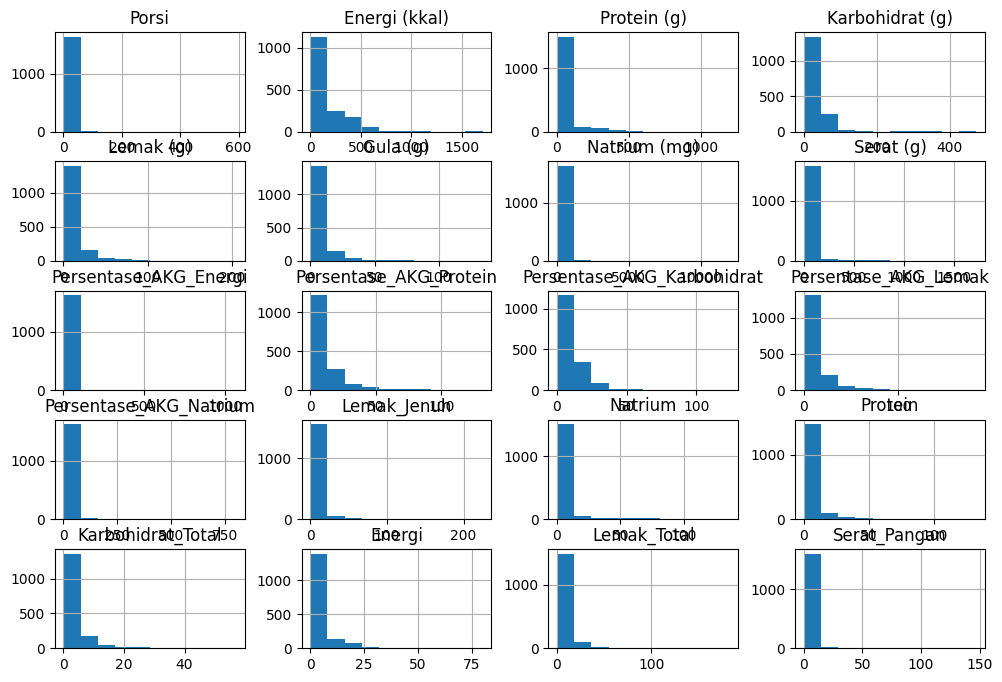

In [21]:
#mengecek distribusi data dengan histogram
nutrition_df.hist(figsize=(12,8))
plt.show()

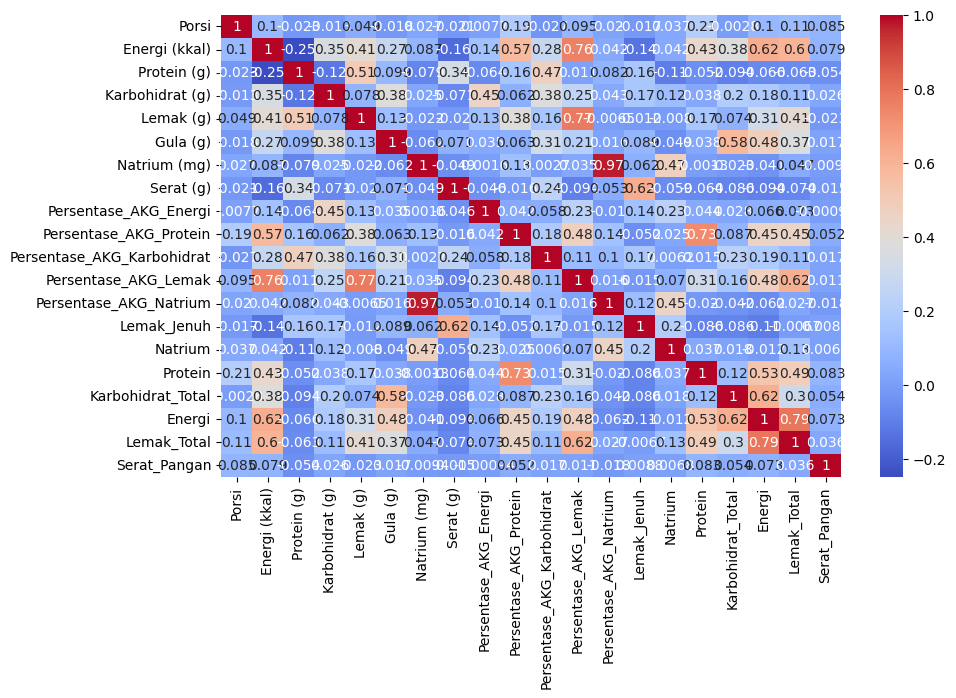

In [22]:
plt.figure(figsize=(10,6))
numeric_df = nutrition_df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [23]:
#mengambil fitur yang akan digunakan untuk analisis

fitur = [
    'Energi (kkal)',
    'Protein (g)',
    'Lemak (g)',
    'Karbohidrat (g)',
    'Gula (g)'
]

X = nutrition_df[fitur]

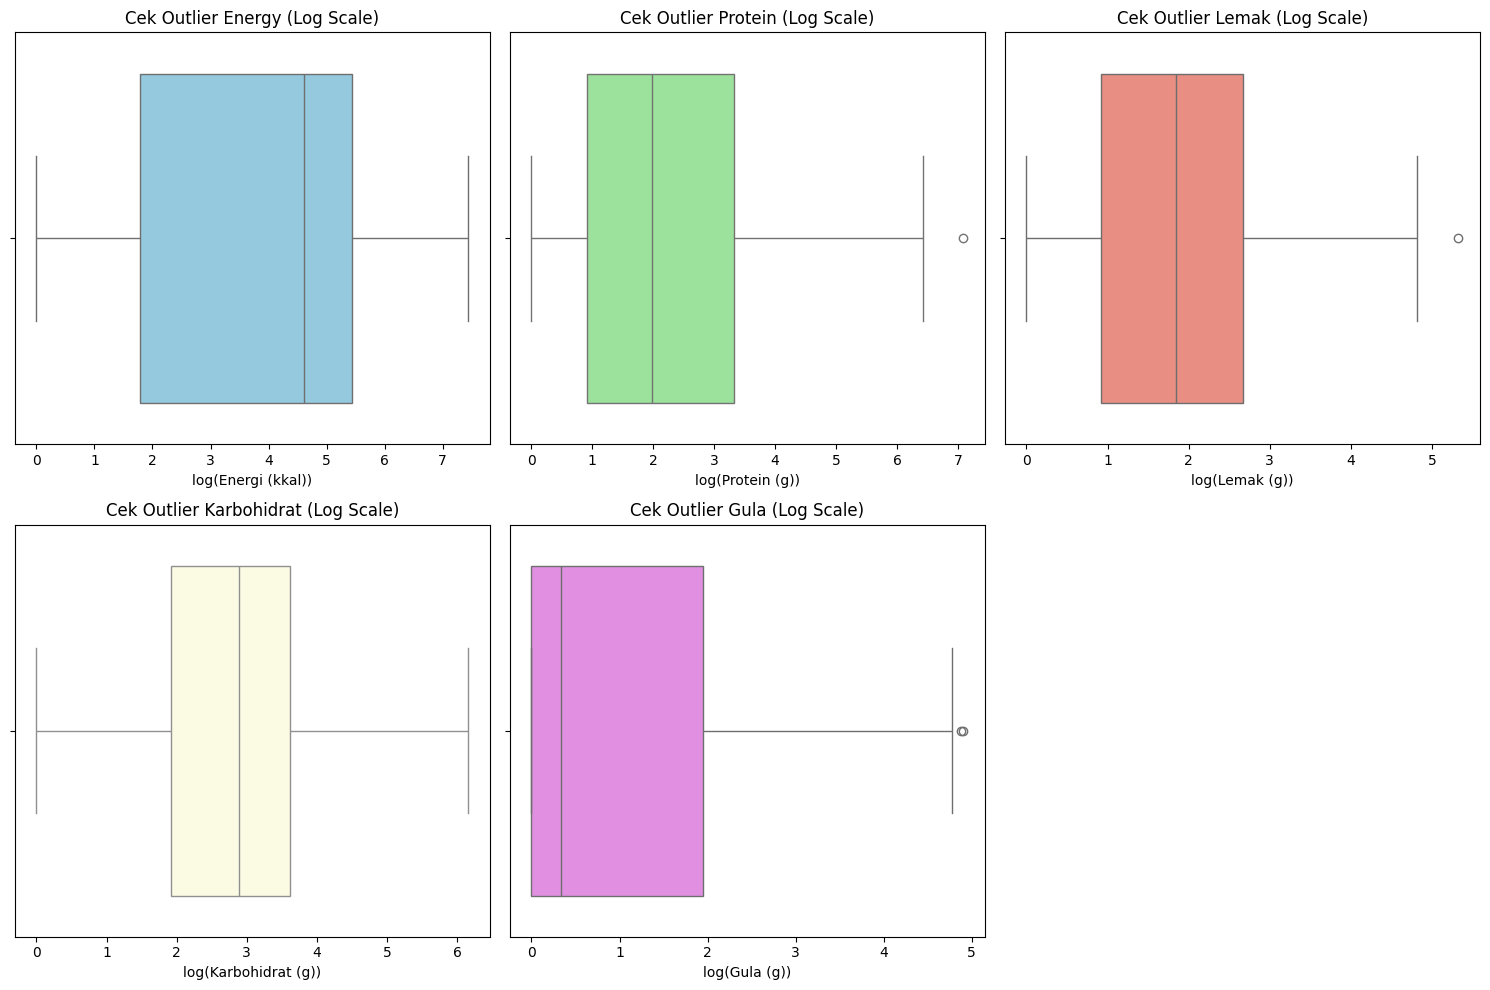

In [24]:
#mengecek outlier

plt.figure(figsize=(15, 10))

# 1. Energy
plt.subplot(2, 3, 1)
sns.boxplot(x=np.log1p(nutrition_df['Energi (kkal)']), color='skyblue')
plt.title('Cek Outlier Energy (Log Scale)')
plt.xlabel('log(Energi (kkal))')

# 2. Protein
plt.subplot(2, 3, 2)
sns.boxplot(x=np.log1p(nutrition_df['Protein (g)']), color='lightgreen')
plt.title('Cek Outlier Protein (Log Scale)')
plt.xlabel('log(Protein (g))')

# 3. Lemak
plt.subplot(2, 3, 3)
sns.boxplot(x=np.log1p(nutrition_df['Lemak (g)']), color='salmon')
plt.title('Cek Outlier Lemak (Log Scale)')
plt.xlabel('log(Lemak (g))')

# 4. Karbohidrat
plt.subplot(2, 3, 4)
sns.boxplot(x=np.log1p(nutrition_df['Karbohidrat (g)']), color='lightyellow')
plt.title('Cek Outlier Karbohidrat (Log Scale)')
plt.xlabel('log(Karbohidrat (g))')

# 5. Gula
plt.subplot(2, 3, 5)
sns.boxplot(x=np.log1p(nutrition_df['Gula (g)']), color='violet')
plt.title('Cek Outlier Gula (Log Scale)')
plt.xlabel('log(Gula (g))')

plt.tight_layout()
plt.show()

In [25]:
#menghitung jumlah outlier menggunakan metode IQR

def cek_outlier_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outlier)} outlier")

for col in ['Energi (kkal)', 'Protein (g)', 'Lemak (g)', 'Karbohidrat (g)', 'Gula (g)']:
    cek_outlier_iqr(nutrition_df, col)

Energi (kkal): 51 outlier
Protein (g): 258 outlier
Lemak (g): 139 outlier
Karbohidrat (g): 91 outlier
Gula (g): 186 outlier


In [26]:
#SCALING DATA

# kolom yang mau di-scaling
cols = ['Energi (kkal)', 'Protein (g)', 'Lemak (g)', 'Karbohidrat (g)', 'Gula (g)']


# inisialisasi scaler
scaler = MinMaxScaler()


# lakukan scaling
nutrition_df[cols] = scaler.fit_transform(nutrition_df[cols])

kolom_final = ['Nama_Makanan'] + cols
nutrition_output = nutrition_df[kolom_final]

print("Data setelah Scaling (MinMaxScaler):")
display(nutrition_output.head())

Data setelah Scaling (MinMaxScaler):


,Nama_Makanan,Energi (kkal),Protein (g),Lemak (g),Karbohidrat (g),Gula (g)
0,Ikan sunu,0.058480,0.016917,0.166341,0.420719,0.052985
1,Soto pekalongan,0.000760,0.078333,0.024878,0.006342,0.050746
2,Marie duo,0.008772,0.000833,0.017073,0.029598,0.037313
3,Kaparende,0.000760,0.031667,0.012683,0.005074,0.014925
4,Kacang lebui / iris,0.202339,0.013750,0.007317,0.140803,0.000000


In [27]:
#Menyimpan dataset yang sudah bersih dan discale ke file CSV baru
nutrition_output.to_csv('dataset_nilai_gizi_scaled_final.csv', index=False,sep=',', decimal='.')

print("Selamat! Dataset sudah berhasil dibersihkan, di-scale, dan disimpan.")
print("File tersimpan dengan nama: dataset_nilai_gizi_scaled_final.csv")

Selamat! Dataset sudah berhasil dibersihkan, di-scale, dan disimpan.
File tersimpan dengan nama: dataset_nilai_gizi_scaled_final.csv
